# Bài 1 — Phân loại ransomware trên bộ dữ liệu BitcoinHeist (UCI)

**Nguồn:** UCI Machine Learning Repository — *BitcoinHeistRansomwareAddressDataset* (Akcora et al., 2019).
Mỗi dòng là một địa chỉ Bitcoin trong một ngày (2011–2018), mô tả bằng các đặc trưng đồ thị giao dịch;
nhãn `label` cho biết địa chỉ thuộc họ ransomware nào (hoặc `white` = không phải ransomware).

**Quy trình:**
1. Đọc & khám phá dữ liệu
2. Định nghĩa lại nhãn (gộp các lớp quá hiếm)
3. Feature engineering + chuẩn hoá (log1p → StandardScaler cho số, One-Hot cho phân loại)
4. **Baseline:** 4 mô hình (Logistic Regression, KNN, Random Forest, HistGradientBoosting)
5. **Cải thiện:** tỉ lệ undersampling, đặc trưng mới, tinh chỉnh siêu tham số, hiệu chỉnh trọng số lớp,
   XGBoost (GPU) / LightGBM, ensemble
6. Phân tích thêm: đánh giá nhị phân, vai trò của `year`, rò rỉ dữ liệu theo `address`

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")

DATA_PATH = "BitcoinHeistData.csv"
OUT_DIR = "outputs"
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_JOBS = -1
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Đọc dữ liệu & khám phá

In [2]:
t0 = time.perf_counter()
df = pd.read_csv(DATA_PATH)
print(f"Đọc xong trong {time.perf_counter() - t0:.1f}s — shape = {df.shape}")
df.head()

Đọc xong trong 1.9s — shape = (2916697, 10)


,address,year,day,length,weight,count,looped,neighbors,income,label
0,111K8kZAEnJg245r2cM6y9zgJGHZtJPy6,2017,11,18,0.0083,1,0,2,100050000.0000,princetonCerber
1,1123pJv8jzeFQaCV4w644pzQJzVWay2zcA,2016,132,44,0.0002,1,0,1,100000000.0000,princetonLocky
2,112536im7hy6wtKbpH1qYDWtTyMRAcA2p7,2016,246,0,1.0000,1,0,2,200000000.0000,princetonCerber
3,1126eDRw2wqSkWosjTCre8cjjQW8sSeWH7,2016,322,72,0.0039,1,0,2,71200000.0000,princetonCerber
4,1129TSjKtx65E35GiUo4AYVeyo48twbrGX,2016,238,144,0.0728,456,0,1,200000000.0000,princetonLocky


In [3]:
df.info()
print("\nGiá trị thiếu:", df.isna().sum().sum())
print("Số địa chỉ khác nhau:", df["address"].nunique())
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 2916697 entries, 0 to 2916696
Data columns (total 10 columns):
 #   Column     Dtype  
---  ------     -----  
 0   address    str    
 1   year       int64  
 2   day        int64  
 3   length     int64  
 4   weight     float64
 5   count      int64  
 6   looped     int64  
 7   neighbors  int64  
 8   income     float64
 9   label      str    
dtypes: float64(2), int64(6), str(2)
memory usage: 222.5 MB

Giá trị thiếu: 0


Số địa chỉ khác nhau: 2631095


,count,mean,std,min,25%,50%,75%,max
year,2916697.0000,2014.4750,2.2574,2011.0000,2013.0000,2014.0000,2016.0000,2018.0000
day,2916697.0000,181.4572,104.0118,1.0000,92.0000,181.0000,271.0000,365.0000
length,2916697.0000,45.0086,58.9824,0.0000,2.0000,8.0000,108.0000,144.0000
weight,2916697.0000,0.5455,3.6743,0.0000,0.0215,0.2500,0.8819,1943.7488
count,2916697.0000,721.6446,1689.6758,1.0000,1.0000,1.0000,56.0000,14497.0000
looped,2916697.0000,238.5067,966.3217,0.0000,0.0000,0.0000,0.0000,14496.0000
neighbors,2916697.0000,2.2065,17.9188,1.0000,1.0000,2.0000,2.0000,12920.0000
income,2916697.0000,4464889007.1862,162685960669.3480,30000000.0000,74285590.0000,199998518.0000,994000000.0000,49964398238996.0000


Số lớp: 29


,count,pct
label,,
white,2875284,98.5801
paduaCryptoWall,12390,0.4248
montrealCryptoLocker,9315,0.3194
princetonCerber,9223,0.3162
princetonLocky,6625,0.2271
montrealCryptXXX,2419,0.0829
montrealNoobCrypt,483,0.0166
montrealDMALockerv3,354,0.0121
montrealDMALocker,251,0.0086


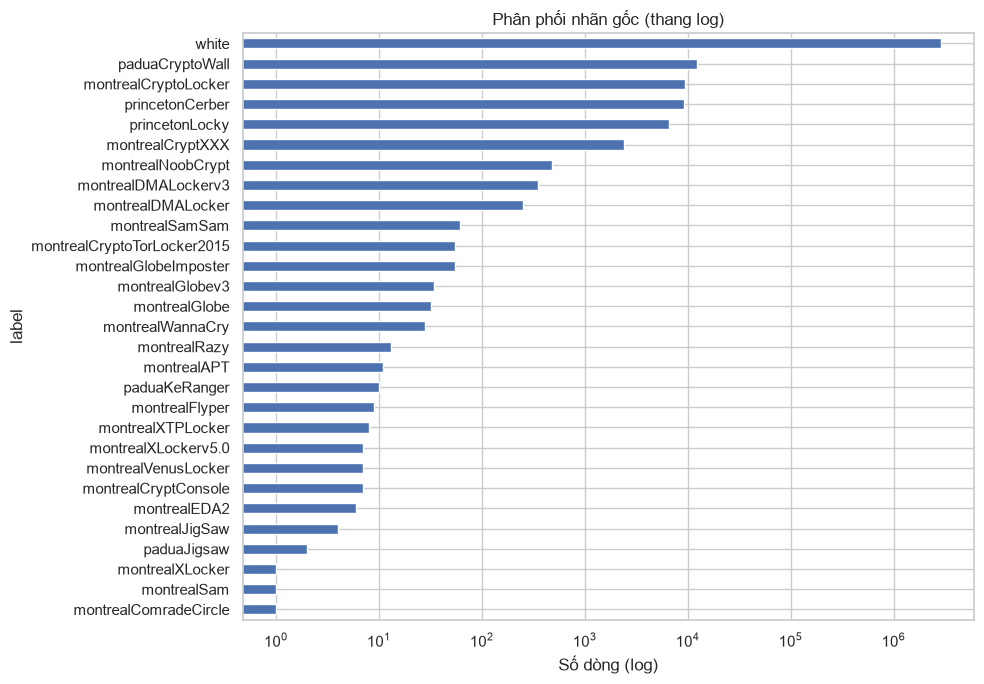

In [4]:
label_counts = df["label"].value_counts()
print(f"Số lớp: {label_counts.size}")
display(label_counts.to_frame("count").assign(pct=lambda d: 100 * d["count"] / d["count"].sum()))

fig, ax = plt.subplots(figsize=(10, 7))
label_counts.sort_values().plot.barh(ax=ax, logx=True)
ax.set(title="Phân phối nhãn gốc (thang log)", xlabel="Số dòng (log)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/label_distribution.png", dpi=120); plt.show()

In [5]:
# Số dòng ransomware theo năm → 'year' là đặc trưng rất mạnh.
# Lưu ý: số dòng 'white' mỗi năm đúng 365.000 (= 1.000/ngày) → 'white' được lấy mẫu cố định theo ngày.
ct = pd.crosstab(df["year"], df["label"] != "white").rename(columns={False: "white", True: "ransomware"})
ct["ransom_pct"] = 100 * ct["ransomware"] / ct.sum(axis=1)
ct

label,white,ransomware,ransom_pct
year,,,
2011,355284,65,0.0183
2012,365000,714,0.1952
2013,365000,7494,2.0118
2014,365000,10319,2.7494
2015,365000,3701,1.0038
2016,365000,15631,4.1066
2017,365000,3486,0.9460
2018,330000,3,0.0009


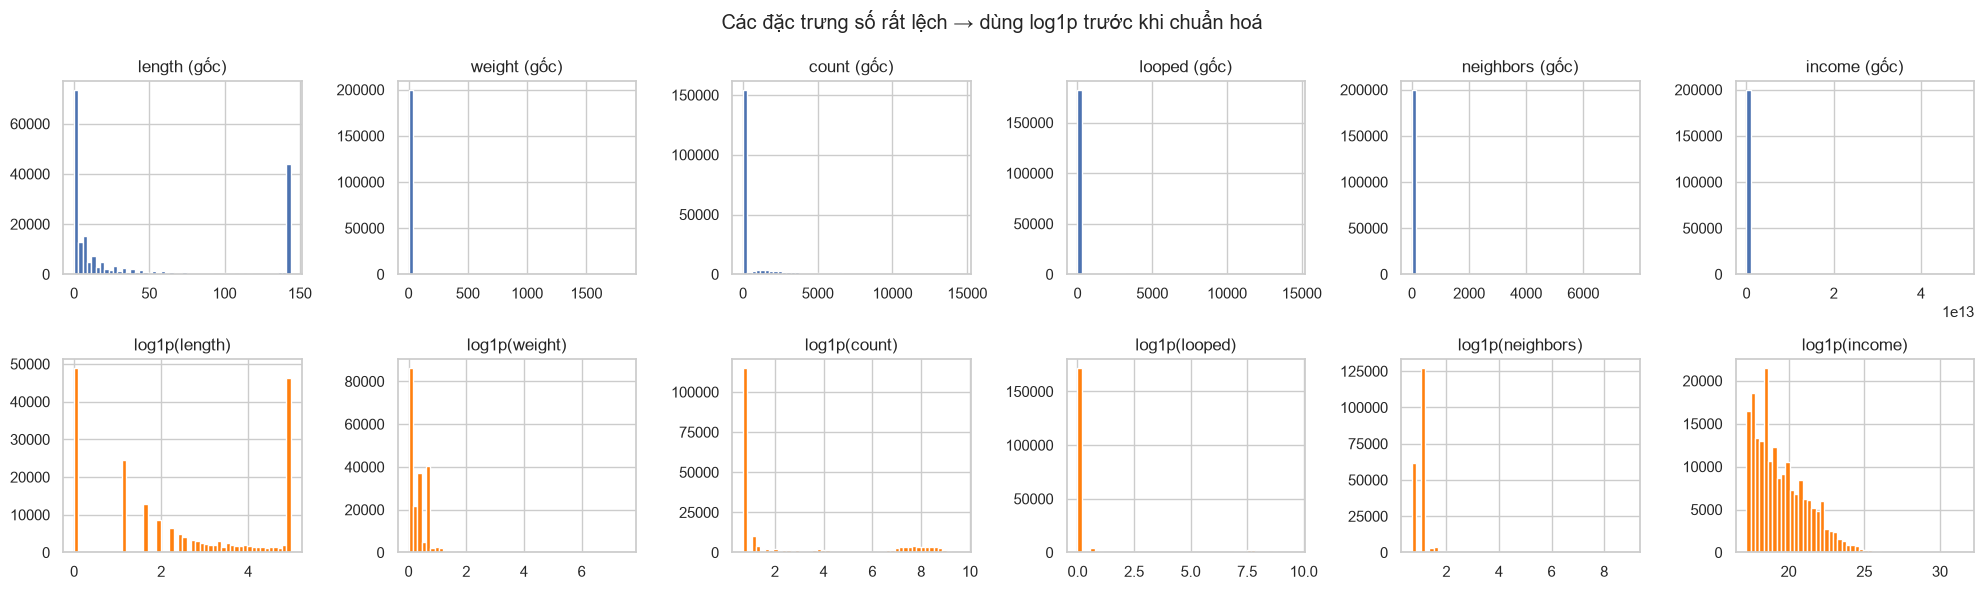

In [6]:
NUM_BASE = ["length", "weight", "count", "looped", "neighbors", "income"]
fig, axes = plt.subplots(2, len(NUM_BASE), figsize=(20, 6))
sample = df[NUM_BASE].sample(200_000, random_state=RANDOM_STATE)
for i, c in enumerate(NUM_BASE):
    axes[0, i].hist(sample[c], bins=50); axes[0, i].set_title(f"{c} (gốc)")
    axes[1, i].hist(np.log1p(sample[c]), bins=50, color="tab:orange"); axes[1, i].set_title(f"log1p({c})")
plt.suptitle("Các đặc trưng số rất lệch → dùng log1p trước khi chuẩn hoá")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/numeric_distributions.png", dpi=120); plt.show()

## 2. Định nghĩa lại nhãn

Dữ liệu có 29 lớp, `white` chiếm ~98,6%, và ~20 lớp chỉ có < 100 mẫu (nhiều lớp 1–10 mẫu) — precision/recall
của những lớp đó vô nghĩa. Ta gộp thành **7 lớp**: `white`, 5 họ ransomware lớn nhất, và `otherRansom`.

In [7]:
TOP_FAMILIES = label_counts.drop("white").head(5).index.tolist()
df["target"] = np.where(df["label"] == "white", "white",
                np.where(df["label"].isin(TOP_FAMILIES), df["label"], "otherRansom"))
CLASSES = sorted(df["target"].unique())
WHITE = "white"
df["target"].value_counts().to_frame("count")

,count
target,
white,2875284
paduaCryptoWall,12390
montrealCryptoLocker,9315
princetonCerber,9223
princetonLocky,6625
montrealCryptXXX,2419
otherRansom,1441


## 3. Feature engineering

- Bỏ `address` (định danh, không phải đặc trưng).
- Ghép `year` + `day` → ngày cụ thể → tạo `month`, `weekday` (đặc trưng **categorical**).
- Đặc trưng **numerical** gốc: `length, weight, count, looped, neighbors, income`.
- **Đặc trưng mới** (dùng ở phần cải thiện):
  - `income_tz`: số chữ số 0 ở cuối của `income` (đơn vị satoshi) — đo độ "tròn" của số tiền nhận; tiền chuộc
    thường là số tròn.
  - `income_per_count`, `income_per_neighbor`, `weight_per_count`, `looped_ratio`: các tỉ lệ giữa đặc trưng gốc.

In [8]:
date = pd.to_datetime(df["year"].astype(str) + "-01-01") + pd.to_timedelta(df["day"] - 1, unit="D")
df["month"] = date.dt.month
df["weekday"] = date.dt.dayofweek

inc_int = df["income"].round().astype("int64")
df["income_tz"] = sum((inc_int % 10**k == 0).astype("int8") for k in range(1, 13))
df["income_per_count"] = df["income"] / df["count"]
df["income_per_neighbor"] = df["income"] / df["neighbors"].clip(lower=1)
df["weight_per_count"] = df["weight"] / df["count"]
df["looped_ratio"] = df["looped"] / df["count"]

NUM_FE = NUM_BASE + ["income_tz", "income_per_count", "income_per_neighbor", "weight_per_count", "looped_ratio"]
CAT = ["year", "month", "weekday"]
X = df[NUM_FE + CAT]
y = df["target"]

# Độ "tròn" của income khác nhau rõ giữa white và ransomware
display(pd.crosstab(df["income_tz"].clip(upper=9), df["target"] == WHITE, normalize="columns")
          .rename(columns={True: "white", False: "ransomware"}).T.style.format("{:.3f}"))

income_tz,0,1,2,3,4,5,6,7,8,9
target,,,,,,,,,,
ransomware,0.162,0.022,0.017,0.014,0.123,0.059,0.144,0.235,0.211,0.012
white,0.454,0.074,0.039,0.038,0.105,0.050,0.109,0.053,0.061,0.017


## 4. Chia train / validation / test & cân bằng dữ liệu

- `train_test_split(stratify=y)` 80/20 → tập **test** giữ **phân phối thật**, chỉ dùng để báo cáo kết quả cuối.
- Tập train tiếp tục tách 80/20 → **train** / **validation**. Validation (phân phối thật) dùng để chọn tỉ lệ
  undersampling, siêu tham số và hiệu chỉnh trọng số lớp — không bao giờ chọn dựa trên tập test.
- Undersample lớp `white` **chỉ trên dữ liệu dùng để fit**.

In [9]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=RANDOM_STATE)

def undersample(X_, y_, n_white, seed=RANDOM_STATE):
    # Giữ n_white mẫu 'white' (None = giữ tất cả) + toàn bộ ransomware
    if n_white is None:
        return X_, y_
    w = y_.index[y_ == WHITE]
    keep = np.concatenate([np.random.RandomState(seed).choice(w, n_white, replace=False), y_.index[y_ != WHITE]])
    return X_.loc[keep], y_.loc[keep]

print("train_full:", X_train_full.shape, "| train:", X_tr.shape, "| val:", X_val.shape, "| test:", X_test.shape)
pd.concat([y_train_full.value_counts().rename("train_full"), y_val.value_counts().rename("val"),
           y_test.value_counts().rename("test")], axis=1)

train_full: (2333357, 14) | train: (1866685, 14) | val: (466672, 14) | test: (583340, 14)


,train_full,val,test
target,,,
white,2300227,460046,575057
paduaCryptoWall,9912,1982,2478
montrealCryptoLocker,7452,1490,1863
princetonCerber,7378,1476,1845
princetonLocky,5300,1060,1325
montrealCryptXXX,1935,387,484
otherRansom,1153,231,288


## 5. Tiền xử lý (chuẩn hoá)

`ColumnTransformer` nằm trong `Pipeline` nên scaler/encoder **chỉ fit trên tập train** (tránh rò rỉ dữ liệu).
One-Hot xuất ma trận **dense** (`sparse_output=False`) vì HistGradientBoosting không nhận dữ liệu sparse.

In [10]:
def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([("log1p", FunctionTransformer(np.log1p)),
                          ("scaler", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ])

make_preprocessor(NUM_BASE, CAT)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 6. Baseline: 4 mô hình

Cấu hình ban đầu: 6 đặc trưng số gốc + 3 đặc trưng phân loại, giữ 200.000 mẫu `white` khi train, không tinh chỉnh.

| Mô hình | Ý tưởng |
|---|---|
| Logistic Regression | Tuyến tính, softmax đa lớp; `class_weight="balanced"` |
| KNN | Dựa trên khoảng cách (k=5) — train gần như tức thì, predict chậm |
| Random Forest | Tập hợp nhiều cây quyết định (bagging) |
| HistGradientBoosting | Boosting trên cây với histogram — nhanh, mạnh với dữ liệu bảng |

In [11]:
def log_progress(msg):
    line = f"{time.strftime('%H:%M:%S')} {msg}"
    print(line, flush=True)
    with open(f"{OUT_DIR}/progress.log", "a", encoding="utf-8") as f:
        f.write(line + "\n")

def summarize(name, y_true, y_pred, t_train, t_test):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return rep, {"model": name, "accuracy": rep["accuracy"],
                 "weighted_precision": rep["weighted avg"]["precision"],
                 "weighted_recall": rep["weighted avg"]["recall"],
                 "weighted_f1": rep["weighted avg"]["f1-score"],
                 "macro_f1": rep["macro avg"]["f1-score"],
                 "binary_f1_ransom": f1_score(np.asarray(y_true) != WHITE, np.asarray(y_pred) != WHITE),
                 "train_time_s": t_train, "test_time_s": t_test}

def fit_pipeline(name, clf, X_fit, y_fit, num_cols, cat_cols=CAT):
    pipe = Pipeline([("pre", make_preprocessor(num_cols, cat_cols)), ("clf", clf)])
    log_progress(f"[{name}] fit ...")
    t0 = time.perf_counter(); pipe.fit(X_fit[num_cols + cat_cols], y_fit); t_train = time.perf_counter() - t0
    log_progress(f"[{name}] fit xong {t_train:.1f}s")
    return pipe, t_train

def evaluate(name, clf, X_fit, y_fit, X_te, y_te, num_cols, cat_cols=CAT, verbose=True):
    pipe, t_train = fit_pipeline(name, clf, X_fit, y_fit, num_cols, cat_cols)
    t0 = time.perf_counter(); y_pred = pipe.predict(X_te[num_cols + cat_cols]); t_test = time.perf_counter() - t0
    log_progress(f"[{name}] predict xong {t_test:.1f}s")
    rep, s = summarize(name, y_te, y_pred, t_train, t_test)
    if verbose:
        print(f"===== {name} =====  train {t_train:.1f}s | test {t_test:.1f}s")
        print(classification_report(y_te, y_pred, digits=4, zero_division=0))
    return pipe, y_pred, rep, s

BASELINE_MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=N_JOBS),
    "RandomForest": RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                           n_jobs=N_JOBS, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, learning_rate=0.1,
                                                           random_state=RANDOM_STATE),
}

X_base_fit, y_base_fit = undersample(X_train_full, y_train_full, 200_000)
base_preds, base_reports, base_rows = {}, {}, []
for name, clf in BASELINE_MODELS.items():
    _, base_preds[name], base_reports[name], s = evaluate(name, clf, X_base_fit, y_base_fit, X_test, y_test, NUM_BASE)
    base_rows.append(s)
baseline = pd.DataFrame(base_rows).set_index("model")
baseline.to_csv(f"{OUT_DIR}/summary_baseline.csv")
baseline

13:59:34 [LogisticRegression] fit ...


13:59:39 [LogisticRegression] fit xong 5.0s


13:59:39 [LogisticRegression] predict xong 0.2s


===== LogisticRegression =====  train 5.0s | test 0.2s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.0248    0.9029    0.0483       484
montrealCryptoLocker     0.0167    0.9002    0.0328      1863
         otherRansom     0.0022    0.5139    0.0044       288
     paduaCryptoWall     0.0304    0.9084    0.0588      2478
     princetonCerber     0.0247    0.7051    0.0477      1845
      princetonLocky     0.0545    0.8868    0.1026      1325
               white     0.9993    0.4343    0.6055    575057

            accuracy                         0.4401    583340
           macro avg     0.1647    0.7502    0.1286    583340
        weighted avg     0.9855    0.4401    0.5977    583340

13:59:50 [KNN] fit ...


13:59:50 [KNN] fit xong 0.4s


14:00:14 [KNN] predict xong 23.7s


===== KNN =====  train 0.4s | test 23.7s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.1176    0.5909    0.1962       484
montrealCryptoLocker     0.0918    0.3323    0.1439      1863
         otherRansom     0.0236    0.0243    0.0239       288
     paduaCryptoWall     0.1399    0.6408    0.2297      2478
     princetonCerber     0.1065    0.5480    0.1783      1845
      princetonLocky     0.1509    0.7170    0.2493      1325
               white     0.9938    0.9448    0.9687    575057

            accuracy                         0.9390    583340
           macro avg     0.2320    0.5426    0.2843    583340
        weighted avg     0.9813    0.9390    0.9577    583340

14:00:27 [RandomForest] fit ...


14:00:30 [RandomForest] fit xong 3.0s


14:00:31 [RandomForest] predict xong 1.4s


===== RandomForest =====  train 3.0s | test 1.4s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.7028    0.7913    0.7444       484
montrealCryptoLocker     0.1639    0.3194    0.2166      1863
         otherRansom     0.0000    0.0000    0.0000       288
     paduaCryptoWall     0.1964    0.6889    0.3056      2478
     princetonCerber     0.2767    0.6228    0.3832      1845
      princetonLocky     0.3361    0.7985    0.4731      1325
               white     0.9942    0.9736    0.9838    575057

            accuracy                         0.9681    583340
           macro avg     0.3814    0.5992    0.4438    583340
        weighted avg     0.9836    0.9681    0.9747    583340

14:00:45 [HistGradientBoosting] fit ...


14:00:47 [HistGradientBoosting] fit xong 2.0s


14:00:48 [HistGradientBoosting] predict xong 1.0s


===== HistGradientBoosting =====  train 2.0s | test 1.0s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.5339    0.8946    0.6687       484
montrealCryptoLocker     0.1703    0.3188    0.2221      1863
         otherRansom     0.0159    0.0382    0.0224       288
     paduaCryptoWall     0.1844    0.7324    0.2946      2478
     princetonCerber     0.3170    0.6542    0.4270      1845
      princetonLocky     0.4242    0.8906    0.5746      1325
               white     0.9948    0.9721    0.9833    575057

            accuracy                         0.9673    583340
           macro avg     0.3772    0.6430    0.4561    583340
        weighted avg     0.9844    0.9673    0.9745    583340



,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_f1,binary_f1_ransom,train_time_s,test_time_s
model,,,,,,,,
LogisticRegression,0.4401,0.9855,0.4401,0.5977,0.1286,0.0475,5.0194,0.1974
KNN,0.9390,0.9813,0.9390,0.9577,0.2843,0.2173,0.3648,23.6512
RandomForest,0.9681,0.9836,0.9681,0.9747,0.4438,0.3508,3.0181,1.3851
HistGradientBoosting,0.9673,0.9844,0.9673,0.9745,0.4561,0.3613,1.9745,1.0431


In [12]:
# Mốc so sánh: luôn đoán 'white'
_, dummy = summarize("Luôn đoán white", y_test, np.full(len(y_test), WHITE), 0, 0)
pd.DataFrame([dummy]).set_index("model")[["accuracy", "weighted_f1", "macro_f1", "binary_f1_ransom"]]

,accuracy,weighted_f1,macro_f1,binary_f1_ransom
model,,,,
Luôn đoán white,0.9858,0.9788,0.1418,0.0000


**Nhận xét baseline:** accuracy/weighted F1 của mọi mô hình đều *thấp hơn* cách "luôn đoán white" (accuracy 0,986),
còn macro F1 chỉ ~0,13–0,47. Logistic Regression bị `class_weight="balanced"` + undersampling đẩy về phía
ransomware: recall cao nhưng precision chỉ vài %. → Cần cải thiện.

## 7. Cải thiện

### 7.1 Hiệu chỉnh trọng số lớp (class-weight / threshold tuning)

Undersampling làm mô hình "tưởng" ransomware phổ biến hơn thực tế. Thay vì `argmax(p)`, ta dự đoán
`argmax(p_k · w_k)` với vector trọng số `w` được tìm (coordinate ascent trên lưới log) để **tối đa macro F1 trên
tập validation** (phân phối thật). Trọng số này sau đó áp dụng nguyên vẹn lên tập test.

In [13]:
CLS_IDX = {c: i for i, c in enumerate(CLASSES)}
K = len(CLASSES)

def macro_f1_fast(y_codes, p_codes):
    cm = np.bincount(y_codes * K + p_codes, minlength=K * K).reshape(K, K)
    tp = np.diag(cm); fp = cm.sum(0) - tp; fn = cm.sum(1) - tp
    d = 2 * tp + fp + fn
    return float(np.mean(np.where(d > 0, 2 * tp / np.maximum(d, 1), 0)))

def tune_class_weights(P, y_true, passes=3):
    y_codes = np.asarray(pd.Series(y_true).map(CLS_IDX))
    w = np.ones(K); grid = np.exp(np.linspace(-5, 5, 41))
    best = macro_f1_fast(y_codes, P.argmax(1))
    for _ in range(passes):
        for k in range(K):
            for g in grid:
                w2 = w.copy(); w2[k] = g
                s = macro_f1_fast(y_codes, (P * w2).argmax(1))
                if s > best + 1e-9:
                    best, w = s, w2
    return w

def predict_weighted(pipe, X_, w, num_cols, cat_cols=CAT):
    # Cột của predict_proba theo thứ tự pipe.classes_ — với nhãn chuỗi hoặc mã số đều trùng thứ tự CLASSES
    P = pipe.predict_proba(X_[num_cols + cat_cols])
    return np.array(CLASSES)[(P * w).argmax(1)], P

def val_macro_f1(clf, n_white, num_cols, cat_cols=CAT, encode=False):
    # Fit trên train (undersample) → chỉnh w trên nửa val A → chấm macro F1 trên nửa val B
    Xf, yf = undersample(X_tr, y_tr, n_white)
    yf = yf.map(CLS_IDX) if encode else yf
    pipe, _ = fit_pipeline("val", clf, Xf, yf, num_cols, cat_cols)
    P = pipe.predict_proba(X_val[num_cols + cat_cols])
    half = np.arange(len(X_val)) % 2 == 0
    w = tune_class_weights(P[half], y_val[half])
    yv = np.asarray(y_val.map(CLS_IDX))
    return (macro_f1_fast(yv[~half], P[~half].argmax(1)),
            macro_f1_fast(yv[~half], (P[~half] * w).argmax(1)))

### 7.2 Chọn tỉ lệ undersampling

Thử giữ 100k / 200k / 500k / 1M / toàn bộ mẫu `white` khi train (HistGradientBoosting mặc định, đặc trưng gốc),
đo macro F1 trên validation trước và sau khi hiệu chỉnh trọng số lớp.

14:01:06 [val] fit ...


14:01:08 [val] fit xong 2.8s


14:01:19 [val] fit ...


14:01:21 [val] fit xong 1.7s


14:01:30 [val] fit ...


14:01:31 [val] fit xong 1.9s


14:01:40 [val] fit ...


14:01:44 [val] fit xong 3.9s


14:01:51 [val] fit ...


14:01:58 [val] fit xong 7.1s


,val_macro_f1_raw,val_macro_f1_adjusted
n_white_train,,
100000,0.4439,0.5166
200000,0.4593,0.4847
500000,0.4588,0.4861
1000000,0.4171,0.4419
1840181,0.3970,0.4286


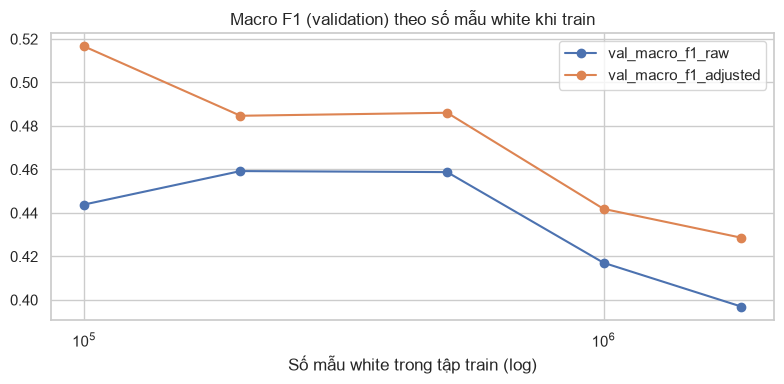

Chọn N_WHITE = 100000


In [14]:
rows = []
for nw in [100_000, 200_000, 500_000, 1_000_000, None]:
    if nw is not None and nw > (y_tr == WHITE).sum():
        continue
    raw, adj = val_macro_f1(HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE), nw, NUM_BASE)
    rows.append({"n_white_train": nw or int((y_tr == WHITE).sum()), "val_macro_f1_raw": raw, "val_macro_f1_adjusted": adj})
us = pd.DataFrame(rows).set_index("n_white_train")
display(us)
ax = us.plot(marker="o", logx=True, figsize=(8, 4), title="Macro F1 (validation) theo số mẫu white khi train")
ax.set_xlabel("Số mẫu white trong tập train (log)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/undersampling.png", dpi=120); plt.show()
N_WHITE = int(us["val_macro_f1_adjusted"].idxmax())
print("Chọn N_WHITE =", N_WHITE)

Giữ ít `white` cho kết quả tốt hơn: với quá nhiều `white`, loss bị lớp này chi phối và early stopping của
HistGradientBoosting dừng trước khi học được các lớp ransomware.

### 7.3 Đặc trưng mới

In [15]:
feat_cmp = pd.DataFrame({
    "6 đặc trưng gốc": val_macro_f1(HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE), N_WHITE, NUM_BASE),
    "11 đặc trưng (gốc + mới)": val_macro_f1(HistGradientBoostingClassifier(max_iter=300, random_state=RANDOM_STATE), N_WHITE, NUM_FE),
}, index=["val_macro_f1_raw", "val_macro_f1_adjusted"]).T
feat_cmp

14:02:06 [val] fit ...


14:02:08 [val] fit xong 2.7s


14:02:19 [val] fit ...


14:02:20 [val] fit xong 1.4s


,val_macro_f1_raw,val_macro_f1_adjusted
6 đặc trưng gốc,0.4439,0.5166
11 đặc trưng (gốc + mới),0.4560,0.5436


### 7.4 Tinh chỉnh siêu tham số

Random search (script `experiments.py`, chạy trên server: 12 cấu hình HGB, 8 LightGBM, 10 XGBoost-GPU,
4 Random Forest), chọn theo macro F1 trên validation. Kết quả tìm kiếm được lưu ở `exp_out/results.json`;
cấu hình tốt nhất được dùng trực tiếp dưới đây.

In [16]:
if os.path.exists("exp_out/results.json"):
    R = json.load(open("exp_out/results.json", encoding="utf-8"))
    search = pd.DataFrame([{"model": r["model"], "val_macro_f1": r["adjusted"]["macro_f1"],
                            "train_s": r["train_s"], **{f"p.{k}": v for k, v in r["params"].items()}}
                           for r in R if r["stage"] == "C_tuning"])
    display(search.sort_values(["model", "val_macro_f1"], ascending=[True, False])
                  .groupby("model").head(3).set_index("model").dropna(axis=1, how="all"))

,val_macro_f1,train_s,p.learning_rate,p.max_leaf_nodes,p.min_samples_leaf,p.l2_regularization,p.max_features,p.num_leaves,p.min_child_samples,p.subsample,p.subsample_freq,p.colsample_bytree,p.reg_lambda,p.n_estimators,p.max_depth,p.min_child_weight
model,,,,,,,,,,,,,,,,
HGB,0.5616,40.0700,0.0300,255.0000,20.0000,10.0000,0.8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HGB,0.5602,9.9000,0.0500,127.0000,20.0000,0.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HGB,0.5595,12.8000,0.0300,31.0000,100.0000,0.0000,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LightGBM,0.5618,6.4200,0.0500,NaN,NaN,NaN,NaN,31.0000,20.0000,0.7000,1.0000,1.0000,1.0000,NaN,NaN,NaN
LightGBM,0.5579,11.4600,0.0500,NaN,NaN,NaN,NaN,63.0000,100.0000,0.7000,1.0000,0.8000,1.0000,NaN,NaN,NaN
LightGBM,0.5557,19.4900,0.0500,NaN,NaN,NaN,NaN,127.0000,50.0000,0.7000,1.0000,1.0000,10.0000,NaN,NaN,NaN
RandomForest,0.5481,2.3000,NaN,NaN,1.0000,NaN,sqrt,NaN,NaN,NaN,NaN,NaN,NaN,300.0000,NaN,NaN
RandomForest,0.5481,2.2800,NaN,NaN,1.0000,NaN,sqrt,NaN,NaN,NaN,NaN,NaN,NaN,300.0000,NaN,NaN
RandomForest,0.5433,4.9700,NaN,NaN,2.0000,NaN,0.5000,NaN,NaN,NaN,NaN,NaN,NaN,300.0000,NaN,NaN


In [17]:
BEST_PARAMS = {
    "HistGradientBoosting": dict(learning_rate=0.03, max_leaf_nodes=255, min_samples_leaf=20,
                                 l2_regularization=10.0, max_features=0.8),
    "LightGBM": dict(learning_rate=0.05, num_leaves=31, min_child_samples=20, subsample=0.7,
                     subsample_freq=1, colsample_bytree=1.0, reg_lambda=1.0, n_estimators=600),
    "XGBoost-GPU": dict(n_estimators=300, learning_rate=0.05, max_depth=12, min_child_weight=1,
                        subsample=0.9, colsample_bytree=0.6, reg_lambda=5.0),
    "RandomForest": dict(n_estimators=300, min_samples_leaf=1, max_features="sqrt", max_depth=None),
}
IMPROVED_MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=N_JOBS),
    "RandomForest": RandomForestClassifier(n_jobs=N_JOBS, random_state=RANDOM_STATE, **BEST_PARAMS["RandomForest"]),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE, early_stopping=True,
                                                           validation_fraction=0.1, n_iter_no_change=30,
                                                           max_iter=2000, **BEST_PARAMS["HistGradientBoosting"]),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1, **BEST_PARAMS["LightGBM"]),
    "XGBoost-GPU": XGBClassifier(device="cuda", tree_method="hist", random_state=RANDOM_STATE,
                                 eval_metric="mlogloss", **BEST_PARAMS["XGBoost-GPU"]),
}

### 7.5 Đánh giá cuối trên tập test

Mỗi mô hình: fit trên train (giữ `N_WHITE` mẫu white + đặc trưng mới) → chỉnh trọng số lớp trên validation →
dự đoán tập test. Thời gian test bao gồm cả bước nhân trọng số.

In [18]:
X_fit, y_fit = undersample(X_tr, y_tr, N_WHITE)
pipes, weights, preds, probas_val, probas_test, reports, rows = {}, {}, {}, {}, {}, {}, []
for name, clf in IMPROVED_MODELS.items():
    y_fit_ = y_fit.map(CLS_IDX) if name == "XGBoost-GPU" else y_fit   # XGBoost cần nhãn dạng số
    pipe, t_train = fit_pipeline(name, clf, X_fit, y_fit_, NUM_FE)
    probas_val[name] = pipe.predict_proba(X_val[NUM_FE + CAT])
    weights[name] = tune_class_weights(probas_val[name], y_val)
    t0 = time.perf_counter()
    preds[name], probas_test[name] = predict_weighted(pipe, X_test, weights[name], NUM_FE)
    t_test = time.perf_counter() - t0
    log_progress(f"[{name}] predict xong {t_test:.1f}s")
    pipes[name] = pipe
    reports[name], s = summarize(name, y_test, preds[name], t_train, t_test)
    rows.append(s)
    print(f"===== {name} =====  train {t_train:.1f}s | test {t_test:.1f}s")
    print(classification_report(y_test, preds[name], digits=4, zero_division=0))

14:02:29 [LogisticRegression] fit ...


14:02:36 [LogisticRegression] fit xong 6.2s


14:02:49 [LogisticRegression] predict xong 0.3s


===== LogisticRegression =====  train 6.2s | test 0.3s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.2919    0.4607    0.3574       484
montrealCryptoLocker     0.1145    0.2056    0.1471      1863
         otherRansom     0.0057    0.3125    0.0112       288
     paduaCryptoWall     0.1479    0.3854    0.2137      2478
     princetonCerber     0.1869    0.3106    0.2334      1845
      princetonLocky     0.4230    0.6015    0.4967      1325
               white     0.9919    0.9522    0.9717    575057

            accuracy                         0.9439    583340
           macro avg     0.3088    0.4612    0.3473    583340
        weighted avg     0.9806    0.9439    0.9614    583340

14:03:01 [KNN] fit ...


14:03:01 [KNN] fit xong 0.2s


14:03:39 [KNN] predict xong 14.1s


===== KNN =====  train 0.2s | test 14.1s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.5082    0.5124    0.5103       484
montrealCryptoLocker     0.1503    0.2727    0.1938      1863
         otherRansom     0.0273    0.0208    0.0236       288
     paduaCryptoWall     0.2167    0.4847    0.2995      2478
     princetonCerber     0.3805    0.4125    0.3958      1845
      princetonLocky     0.4011    0.6626    0.4997      1325
               white     0.9921    0.9826    0.9874    575057

            accuracy                         0.9748    583340
           macro avg     0.3823    0.4783    0.4157    583340
        weighted avg     0.9820    0.9748    0.9780    583340

14:03:50 [RandomForest] fit ...


14:03:52 [RandomForest] fit xong 2.3s


14:04:10 [RandomForest] predict xong 2.0s


===== RandomForest =====  train 2.3s | test 2.0s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.8734    0.8698    0.8716       484
montrealCryptoLocker     0.2305    0.3022    0.2615      1863
         otherRansom     0.0391    0.0972    0.0557       288
     paduaCryptoWall     0.3267    0.4605    0.3822      2478
     princetonCerber     0.6390    0.6016    0.6198      1845
      princetonLocky     0.6346    0.7917    0.7045      1325
               white     0.9933    0.9894    0.9913    575057

            accuracy                         0.9827    583340
           macro avg     0.5338    0.5875    0.5552    583340
        weighted avg     0.9855    0.9827    0.9840    583340

14:04:20 [HistGradientBoosting] fit ...


14:04:57 [HistGradientBoosting] fit xong 37.4s


14:05:30 [HistGradientBoosting] predict xong 8.0s


===== HistGradientBoosting =====  train 37.4s | test 8.0s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.8451    0.8905    0.8672       484
montrealCryptoLocker     0.2794    0.2727    0.2760      1863
         otherRansom     0.0845    0.0833    0.0839       288
     paduaCryptoWall     0.3650    0.4709    0.4113      2478
     princetonCerber     0.6053    0.6466    0.6253      1845
      princetonLocky     0.6927    0.7638    0.7265      1325
               white     0.9933    0.9916    0.9924    575057

            accuracy                         0.9850    583340
           macro avg     0.5522    0.5885    0.5689    583340
        weighted avg     0.9858    0.9850    0.9854    583340

14:05:40 [LightGBM] fit ...


14:05:47 [LightGBM] fit xong 6.3s


14:06:16 [LightGBM] predict xong 8.8s


===== LightGBM =====  train 6.3s | test 8.8s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.8223    0.8988    0.8588       484
montrealCryptoLocker     0.2511    0.3033    0.2747      1863
         otherRansom     0.0696    0.1250    0.0894       288
     paduaCryptoWall     0.3396    0.5218    0.4115      2478
     princetonCerber     0.6701    0.5935    0.6295      1845
      princetonLocky     0.6821    0.7789    0.7273      1325
               white     0.9935    0.9901    0.9918    575057

            accuracy                         0.9836    583340
           macro avg     0.5469    0.6016    0.5690    583340
        weighted avg     0.9860    0.9836    0.9847    583340

14:06:28 [XGBoost-GPU] fit ...


14:06:41 [XGBoost-GPU] fit xong 13.5s


14:06:57 [XGBoost-GPU] predict xong 0.7s


===== XGBoost-GPU =====  train 13.5s | test 0.7s


                      precision    recall  f1-score   support

    montrealCryptXXX     0.8036    0.9215    0.8585       484
montrealCryptoLocker     0.2698    0.2995    0.2839      1863
         otherRansom     0.1070    0.1111    0.1090       288
     paduaCryptoWall     0.3639    0.4826    0.4149      2478
     princetonCerber     0.6146    0.6482    0.6310      1845
      princetonLocky     0.6830    0.7887    0.7320      1325
               white     0.9935    0.9911    0.9923    575057

            accuracy                         0.9847    583340
           macro avg     0.5479    0.6061    0.5745    583340
        weighted avg     0.9860    0.9847    0.9853    583340



### 7.6 Ensemble

Trung bình xác suất của 3 mô hình boosting (HGB, LightGBM, XGBoost), rồi chỉnh trọng số lớp như trên.

In [19]:
ENS = ["HistGradientBoosting", "LightGBM", "XGBoost-GPU"]
P_val = np.mean([probas_val[m] for m in ENS], axis=0)
P_test = np.mean([probas_test[m] for m in ENS], axis=0)
weights["Ensemble"] = tune_class_weights(P_val, y_val)
preds["Ensemble"] = np.array(CLASSES)[(P_test * weights["Ensemble"]).argmax(1)]
t_ens_train = sum(r["train_time_s"] for r in rows if r["model"] in ENS)
t_ens_test = sum(r["test_time_s"] for r in rows if r["model"] in ENS)
reports["Ensemble"], s = summarize("Ensemble", y_test, preds["Ensemble"], t_ens_train, t_ens_test)
rows.append(s)
print(classification_report(y_test, preds["Ensemble"], digits=4, zero_division=0))

summary = pd.DataFrame(rows).set_index("model")
summary.to_csv(f"{OUT_DIR}/summary_improved.csv")
summary

                      precision    recall  f1-score   support

    montrealCryptXXX     0.8574    0.8946    0.8756       484
montrealCryptoLocker     0.2663    0.3086    0.2859      1863
         otherRansom     0.0914    0.1111    0.1003       288
     paduaCryptoWall     0.3485    0.5085    0.4135      2478
     princetonCerber     0.6452    0.6249    0.6349      1845
      princetonLocky     0.6604    0.8204    0.7317      1325
               white     0.9936    0.9905    0.9921    575057

            accuracy                         0.9842    583340
           macro avg     0.5518    0.6084    0.5763    583340
        weighted avg     0.9861    0.9842    0.9851    583340



,accuracy,weighted_precision,weighted_recall,weighted_f1,macro_f1,binary_f1_ransom,train_time_s,test_time_s
model,,,,,,,,
LogisticRegression,0.9439,0.9806,0.9439,0.9614,0.3473,0.1928,6.2099,0.2904
KNN,0.9748,0.9820,0.9748,0.9780,0.4157,0.3449,0.2133,14.0522
RandomForest,0.9827,0.9855,0.9827,0.9840,0.5552,0.4700,2.2969,1.9984
HistGradientBoosting,0.9850,0.9858,0.9850,0.9854,0.5689,0.5034,37.4160,7.9843
LightGBM,0.9836,0.9860,0.9836,0.9847,0.5690,0.4892,6.2782,8.8183
XGBoost-GPU,0.9847,0.9860,0.9847,0.9853,0.5745,0.5069,13.4778,0.7310
Ensemble,0.9842,0.9861,0.9842,0.9851,0.5763,0.5034,57.1721,17.5337


## 8. So sánh kết quả

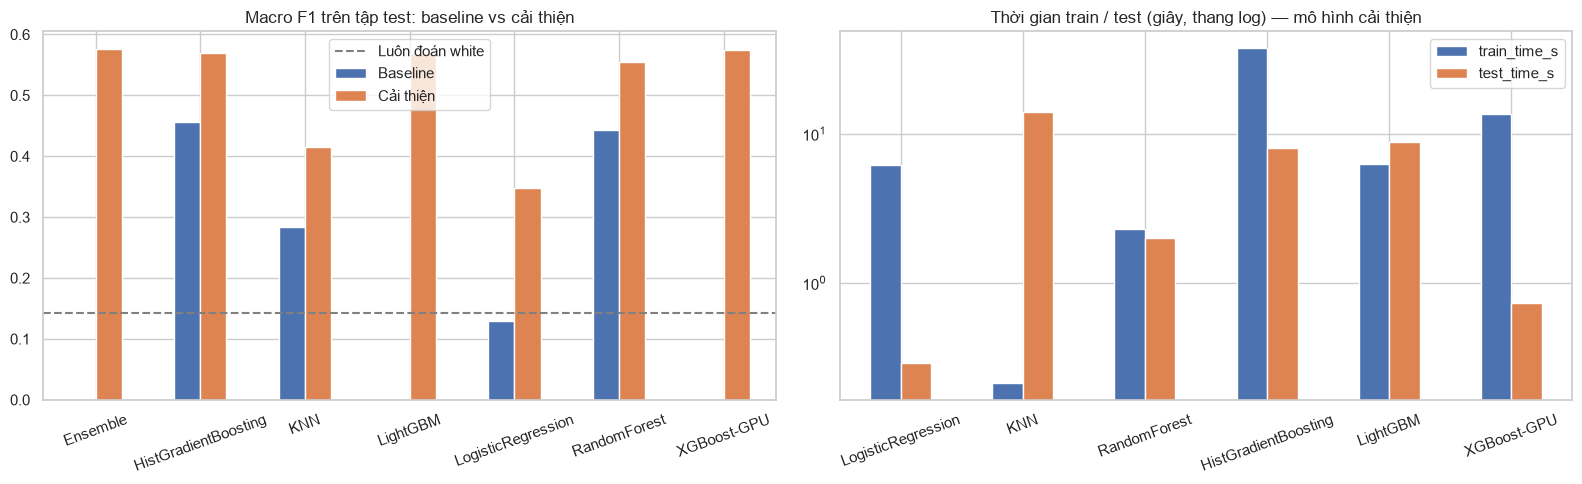

In [20]:
cmp = pd.concat({"Baseline": baseline[["accuracy", "weighted_f1", "macro_f1", "binary_f1_ransom"]],
                 "Cải thiện": summary[["accuracy", "weighted_f1", "macro_f1", "binary_f1_ransom"]]})
display(cmp.style.background_gradient(cmap="Greens", subset=["macro_f1", "binary_f1_ransom"]).format("{:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
m = pd.DataFrame({"Baseline": baseline["macro_f1"], "Cải thiện": summary["macro_f1"]})
m.plot.bar(ax=axes[0]); axes[0].set(title="Macro F1 trên tập test: baseline vs cải thiện", xlabel="")
axes[0].axhline(dummy["macro_f1"], ls="--", c="gray", label="Luôn đoán white"); axes[0].legend()
axes[0].tick_params(axis="x", rotation=20)
summary.drop(index="Ensemble")[["train_time_s", "test_time_s"]].plot.bar(ax=axes[1], logy=True)
axes[1].set(title="Thời gian train / test (giây, thang log) — mô hình cải thiện", xlabel="")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=120); plt.show()

model,LogisticRegression,KNN,RandomForest,HistGradientBoosting,LightGBM,XGBoost-GPU,Ensemble
class,,,,,,,
montrealCryptXXX,0.357,0.510,0.872,0.867,0.859,0.859,0.876
montrealCryptoLocker,0.147,0.194,0.261,0.276,0.275,0.284,0.286
otherRansom,0.011,0.024,0.056,0.084,0.089,0.109,0.100
paduaCryptoWall,0.214,0.300,0.382,0.411,0.411,0.415,0.414
princetonCerber,0.233,0.396,0.620,0.625,0.629,0.631,0.635
princetonLocky,0.497,0.500,0.704,0.726,0.727,0.732,0.732
white,0.972,0.987,0.991,0.992,0.992,0.992,0.992


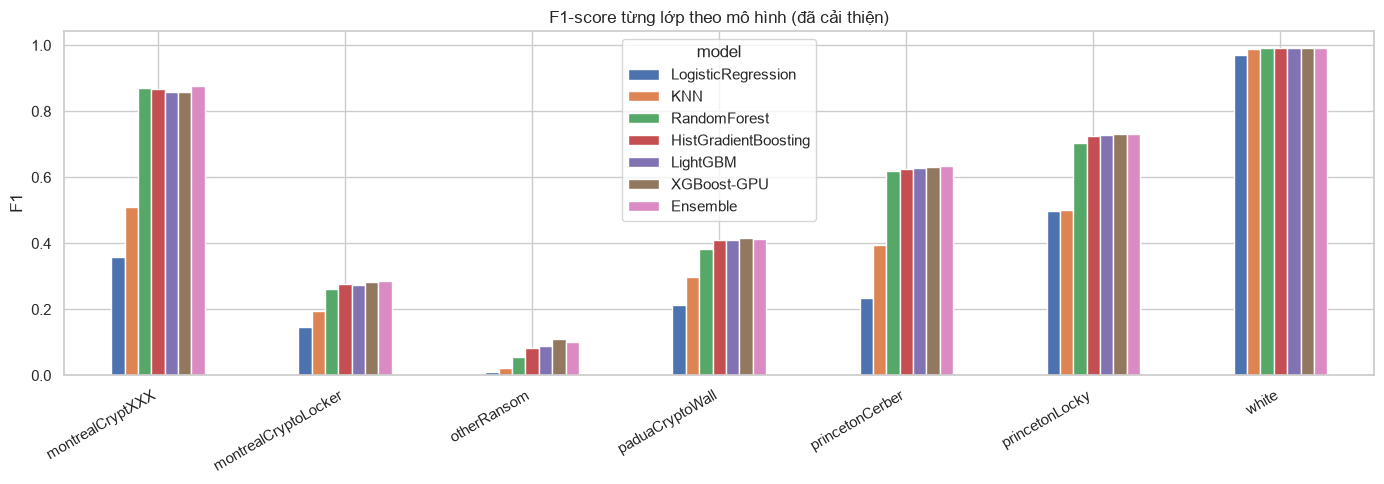

In [21]:
# Precision / Recall / F1 từng lớp — mô hình cải thiện
per_class = pd.concat({
    m: pd.DataFrame({c: reports[m][c] for c in CLASSES}).T[["precision", "recall", "f1-score", "support"]]
    for m in reports}, names=["model", "class"])
per_class.to_csv(f"{OUT_DIR}/per_class_improved.csv")
f1_pivot = per_class["f1-score"].unstack("model")[list(reports)]
display(f1_pivot.style.background_gradient(cmap="Greens", axis=None).format("{:.3f}"))

fig, ax = plt.subplots(figsize=(14, 5))
f1_pivot.plot.bar(ax=ax)
ax.set(title="F1-score từng lớp theo mô hình (đã cải thiện)", ylabel="F1", xlabel="")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/f1_per_class.png", dpi=120); plt.show()

Tốt nhất theo macro F1: Ensemble


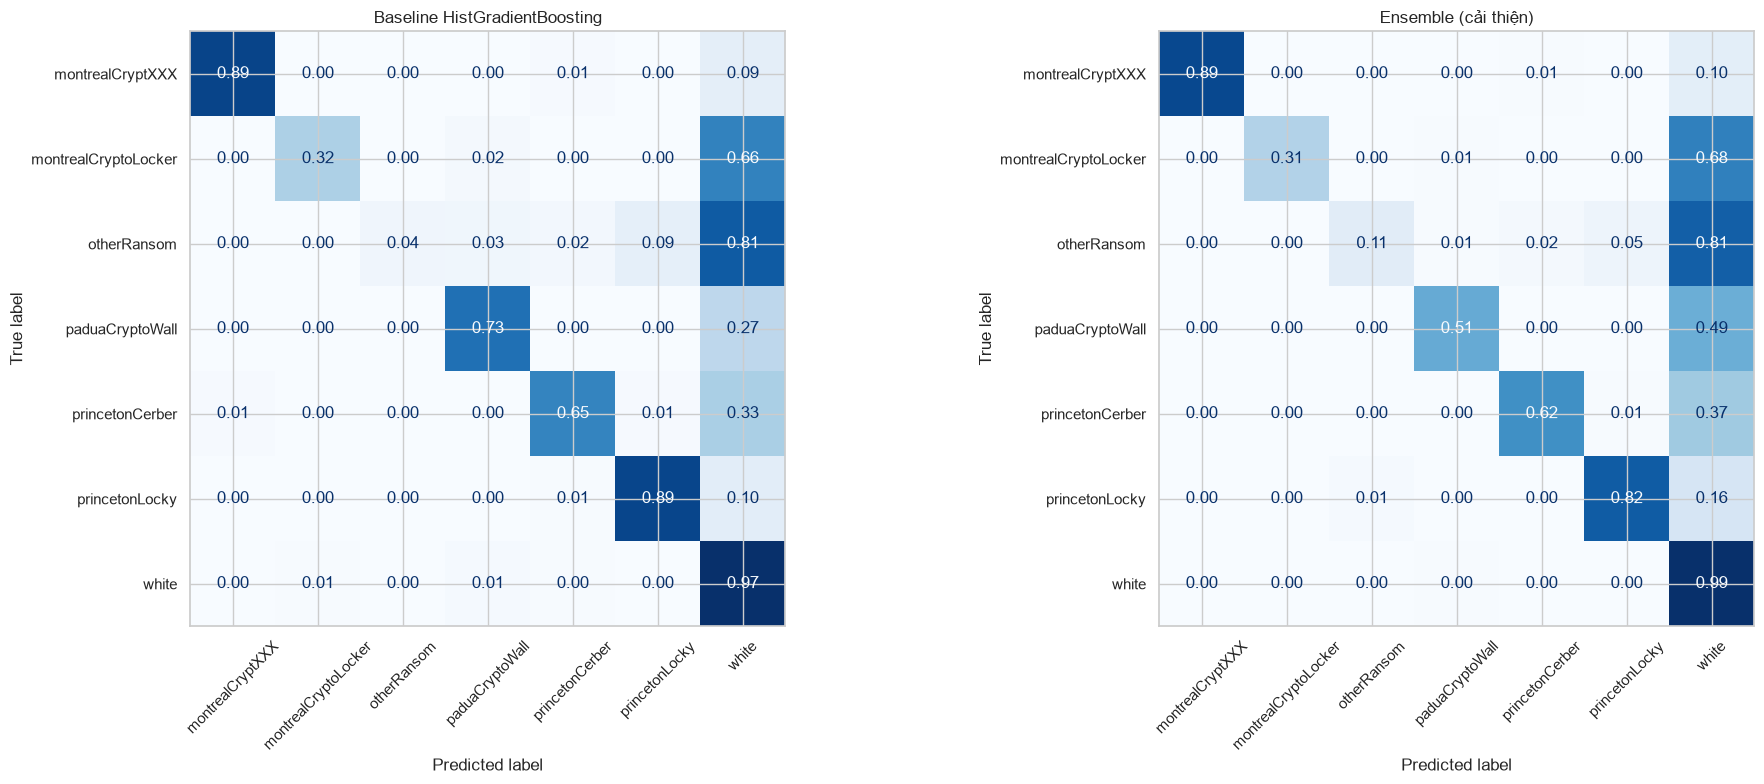

In [22]:
best_name = summary["macro_f1"].idxmax()
print("Tốt nhất theo macro F1:", best_name)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
ConfusionMatrixDisplay.from_predictions(y_test, base_preds["HistGradientBoosting"], labels=CLASSES, normalize="true",
                                        values_format=".2f", cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Baseline HistGradientBoosting")
ConfusionMatrixDisplay.from_predictions(y_test, preds[best_name], labels=CLASSES, normalize="true",
                                        values_format=".2f", cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title(f"{best_name} (cải thiện)")
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_matrices.png", dpi=120); plt.show()

## 9. Phân tích thêm

### 9.1 Đánh giá nhị phân: phát hiện ransomware (bất kể họ nào)

In [23]:
yt_bin = np.where(y_test == WHITE, "white", "ransomware")
yp_bin = np.where(preds[best_name] == WHITE, "white", "ransomware")
print(f"{best_name} — white vs ransomware")
print(classification_report(yt_bin, yp_bin, digits=4))

Ensemble — white vs ransomware


              precision    recall  f1-score   support

  ransomware     0.4589    0.5575    0.5034      8283
       white     0.9936    0.9905    0.9921    575057

    accuracy                         0.9844    583340
   macro avg     0.7263    0.7740    0.7478    583340
weighted avg     0.9860    0.9844    0.9851    583340



Phát hiện "có phải ransomware không" dễ hơn phân biệt *họ* ransomware: phần lớn lỗi còn lại là nhầm giữa các họ
(xem ma trận nhầm lẫn) và báo nhầm địa chỉ `white`.

### 9.2 Vai trò của `year`

In [24]:
best_single = summary.drop(index="Ensemble")["macro_f1"].idxmax()
clf_noyear = clone(IMPROVED_MODELS[best_single])
y_fit_ = y_fit.map(CLS_IDX) if best_single == "XGBoost-GPU" else y_fit
pipe_ny, t_ny = fit_pipeline(f"{best_single} (no year)", clf_noyear, X_fit, y_fit_, NUM_FE, ["month", "weekday"])
w_ny = tune_class_weights(pipe_ny.predict_proba(X_val[NUM_FE + ["month", "weekday"]]), y_val)
p_ny, _ = predict_weighted(pipe_ny, X_test, w_ny, NUM_FE, ["month", "weekday"])
_, s_ny = summarize(f"{best_single} (no year)", y_test, p_ny, t_ny, 0)
pd.DataFrame([summary.loc[best_single].rename(best_single), pd.Series(s_ny).drop("model").rename(s_ny["model"])]
            )[["accuracy", "weighted_f1", "macro_f1", "binary_f1_ransom"]]

14:07:37 [XGBoost-GPU (no year)] fit ...


14:07:54 [XGBoost-GPU (no year)] fit xong 17.3s


,accuracy,weighted_f1,macro_f1,binary_f1_ransom
XGBoost-GPU,0.9847,0.9853,0.5745,0.5069
XGBoost-GPU (no year),0.9820,0.9818,0.4436,0.3561


### 9.3 Rò rỉ dữ liệu theo `address`

Cùng một địa chỉ có thể xuất hiện nhiều ngày. Với phép chia ngẫu nhiên, một địa chỉ ransomware có thể nằm ở cả
train và test → mô hình "nhận ra" hành vi của chính địa chỉ đó → kết quả lạc quan. Kiểm tra mức chồng lấn và so
sánh với phép chia theo nhóm địa chỉ (`GroupShuffleSplit`, script `experiments_group.py`).

In [25]:
addr = df["address"]
in_train = addr.loc[X_test.index].isin(set(addr.loc[X_train_full.index]))
is_ransom = y_test != WHITE
pd.Series({"Tất cả dòng test": in_train.mean(), "Dòng test ransomware": in_train[is_ransom].mean(),
           "Dòng test white": in_train[~is_ransom].mean()}, name="tỉ lệ có address xuất hiện trong train").to_frame()

,tỉ lệ có address xuất hiện trong train
Tất cả dòng test,0.1227
Dòng test ransomware,0.5467
Dòng test white,0.1166


In [26]:
if os.path.exists("exp_out/group_results.json"):
    G = pd.DataFrame(json.load(open("exp_out/group_results.json", encoding="utf-8")))
    display(G.set_index(["split", "model"])[["macro_f1", "weighted_f1", "binary_f1_ransom"]])
    display(pd.DataFrame({(r["split"], r["model"]): r["per_class_f1"] for r in G.to_dict("records")}).round(3))

macro_f1  weighted_f1  binary_f1_ransom
split            model                                               
random           HGB            0.5689       0.9854            0.5034
                 XGBoost-GPU    0.5745       0.9853            0.5069
group_by_address HGB            0.5581       0.9856            0.4865
                 XGBoost-GPU    0.5651       0.9858            0.4966

random             group_by_address            
                        HGB XGBoost-GPU              HGB XGBoost-GPU
montrealCryptXXX     0.8670      0.8580           0.8850      0.8870
montrealCryptoLocker 0.2760      0.2840           0.2170      0.2400
otherRansom          0.0840      0.1090           0.0870      0.0840
paduaCryptoWall      0.4110      0.4150           0.3680      0.3820
princetonCerber      0.6250      0.6310           0.6250      0.6340
princetonLocky       0.7260      0.7320           0.7310      0.7360
white                0.9920      0.9920           0.9920      0.9920

## 10. Lưu mô hình & kết quả (dùng lại cho Bài 3 — Streamlit)

In [27]:
save_name = best_single
pipe_to_save = pipes[save_name]
if save_name == "XGBoost-GPU":
    pipe_to_save.named_steps["clf"].set_params(device="cpu")   # để chạy được trên máy không có GPU
joblib.dump({"pipeline": pipe_to_save, "class_weights": weights[save_name], "classes": CLASSES,
             "num": NUM_FE, "cat": CAT, "top_families": TOP_FAMILIES, "label_encoded": save_name == "XGBoost-GPU"},
            f"{OUT_DIR}/best_model.joblib", compress=3)
print("Đã lưu", save_name, "→", f"{OUT_DIR}/best_model.joblib")
print(sorted(os.listdir(OUT_DIR)))

Đã lưu XGBoost-GPU → outputs/best_model.joblib
['best_model.joblib', 'confusion_matrices.png', 'f1_per_class.png', 'label_distribution.png', 'model_comparison.png', 'numeric_distributions.png', 'per_class_improved.csv', 'progress.log', 'summary_baseline.csv', 'summary_improved.csv', 'undersampling.png']


## 11. Nhận xét

**Kết quả trên tập test (583.340 dòng, phân phối thật):**

| | Macro F1 | Weighted F1 | Accuracy | F1 nhị phân (ransomware) |
|---|---|---|---|---|
| Luôn đoán `white` | 0,142 | 0,979 | 0,986 | 0,000 |
| Baseline tốt nhất (HistGradientBoosting) | 0,456 | 0,975 | 0,967 | 0,361 |
| **XGBoost-GPU (cải thiện)** | **0,575** | 0,985 | 0,985 | 0,507 |
| **Ensemble HGB + LightGBM + XGBoost** | **0,576** | 0,985 | 0,984 | 0,503 |

- Macro F1 tăng **0,456 → 0,576** (+26%), F1 phát hiện ransomware tăng **0,361 → 0,503**. F1 từng họ đều tăng:
  CryptXXX 0,67 → 0,88; Locky 0,57 → 0,73; Cerber 0,43 → 0,63; CryptoWall 0,29 → 0,41; CryptoLocker 0,22 → 0,29.
- **Đóng góp của từng bước** (macro F1 trên validation): hiệu chỉnh trọng số lớp + giữ 100k mẫu white
  0,444 → 0,517; thêm đặc trưng mới → 0,544; tinh chỉnh siêu tham số → ~0,56–0,57.
  Hiệu chỉnh trọng số lớp cũng cứu được các mô hình yếu: Logistic Regression 0,129 → 0,347, KNN 0,284 → 0,416.
- **Thời gian:** KNN train nhanh nhất (0,2s) nhưng test chậm (14s); XGBoost trên GPU vừa tốt nhất vừa dự đoán nhanh
  nhất trong nhóm boosting (0,7s). HGB sau tinh chỉnh (255 lá, learning rate 0,03) train lâu hơn hẳn baseline (37s).
- **Accuracy không phù hợp** cho bài toán mất cân bằng này: mô hình tốt nhất vẫn chỉ ngang cách "luôn đoán white"
  về accuracy, trong khi macro F1 cho thấy khác biệt rõ.
- **`year` rất quan trọng:** bỏ `year` thì macro F1 giảm 0,575 → 0,444 (tỉ lệ ransomware khác nhau nhiều theo năm).
- **Rò rỉ theo `address`:** 54,7% dòng ransomware trong test có địa chỉ xuất hiện trong train, nhưng khi chia theo
  nhóm địa chỉ macro F1 chỉ giảm ~0,01 (XGBoost 0,575 → 0,565) → kết quả đáng tin cậy.
- **Hạn chế:** ở mức nhị phân, precision ransomware ~46% và recall ~56% — vẫn còn nhiều báo nhầm. Các họ
  CryptoLocker / CryptoWall khó tách nhau, `otherRansom` (gộp nhiều họ hiếm) gần như không học được (F1 ~0,1).
  Bộ dữ liệu chỉ có 6 đặc trưng đồ thị nên đây là giới hạn của dữ liệu nhiều hơn của mô hình.